<a href="https://colab.research.google.com/github/furkandr01/python_data_science/blob/main/Odev7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
veri_yolu = '/content/drive/MyDrive/Tech Istanbul/musteri_segmentasyonu.csv'

In [ ]:
veri = pd.read_csv(veri_yolu)
print(veri.head(10))

   yillik_gelir  harcama_puani
0          16.8           88.3
1          45.6           40.3
2          44.7           49.1
3          87.7           92.7
4          34.1           81.0
5          57.5           61.5
6          26.8           66.7
7          63.5           44.7
8          79.9           76.1
9          23.4           32.2


In [ ]:
X = veri[['yillik_gelir', 'harcama_puani']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

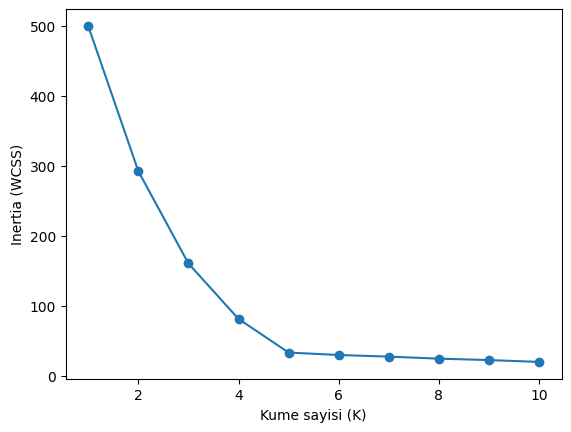

In [ ]:
k_values = range(1, 11)
inertia_list = []

for k in k_values:
 kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeans.fit(X_scaled)
 inertia_list.append(kmeans.inertia_)

plt.plot(k_values, inertia_list, marker="o")
plt.xlabel("Kume sayisi (K)")
plt.ylabel("Inertia (WCSS)")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
centers = kmeans.cluster_centers_
labels = kmeans.labels_

centers_orig = scaler.inverse_transform(centers)

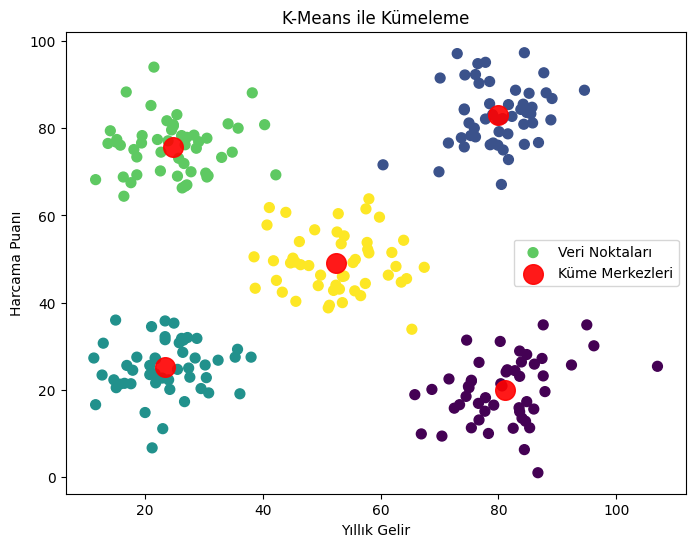

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X['yillik_gelir'], X['harcama_puani'],c=labels, s=50, label='Veri Noktaları')
plt.scatter(centers_orig[:,0], centers_orig[:,1],c='red',s=200, alpha=0.9,label='Küme Merkezleri')

plt.title('K-Means ile Kümeleme')
plt.xlabel('Yıllık Gelir')
plt.ylabel('Harcama Puanı')
plt.legend()
plt.show()

Yeşil küme(sol üst) = düşük gelir ama yüksek harcama var, bu kişiler bütçelerinin üzerinde harcama yapıyor olabilir

Lacivert küme(sağ üst) = yüksek gelir yüksek harcama var, en değerli müşteri tipi olabilir

Sarı küme(orta) = orta gelir orta harcama var, dengeli ve sıradan müşteri

Mavi küme(sol alt) = düşük gelir düşük harcama var, tutarlı davranış görünüyor gibi

Mor küme(sağ alt) = yüksek gelir ama düşük harcama söz konusu, satış arttırmak için hedef kitle burası olabilir

In [ ]:
silhouette = silhouette_score(X_scaled, labels)
print(silhouette)

0.6800509512917465
